In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [ ]:
orders=pd.read_csv("olist_orders_dataset.csv")
items=pd.read_csv("olist_order_items_dataset.csv")
products=pd.read_csv("olist_products_dataset.csv")



In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
items.isnull().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [ ]:
products.isnull().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [ ]:
merged_df=pd.merge(orders,items,on="order_id",how='inner')
merged_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [ ]:
final_df=pd.merge(merged_df,products,on="product_id",how='inner')
final_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [ ]:
final_df['product_category_name']=final_df['product_category_name'].fillna('Unknown')
final_df=final_df.dropna(subset=['product_weight_g'])
final_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,1,d0b61bfb1de832b15ba9d266ca96e5b0,...,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,1,65266b2da20d04dbe00c5c2d3bb7859e,...,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [ ]:
df=final_df[['order_id','order_purchase_timestamp','order_status','price','freight_value','product_category_name','product_weight_g']]
df.head()
df.to_csv('final_dataset.csv',index=False)

In [ ]:
df.isnull().sum()

,0
order_id,0
order_purchase_timestamp,0
order_status,0
price,0
freight_value,0
product_category_name,0
product_weight_g,0


In [ ]:
df.duplicated().sum()

np.int64(10485)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102147 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  102147 non-null  object 
 1   order_purchase_timestamp  102147 non-null  object 
 2   order_status              102147 non-null  object 
 3   price                     102147 non-null  float64
 4   freight_value             102147 non-null  float64
 5   product_category_name     102147 non-null  object 
 6   product_weight_g          102147 non-null  float64
dtypes: float64(3), object(4)
memory usage: 6.2+ MB


In [ ]:
df.describe()

,price,freight_value,product_weight_g
count,102147.000000,102147.000000,102147.000000
mean,124.572249,20.125359,2094.201455
std,188.936821,15.898454,3753.773954
min,0.850000,0.000000,0.000000
25%,40.500000,13.150000,300.000000
50%,78.900000,16.330000,700.000000
75%,139.000000,21.225000,1800.000000
max,6735.000000,409.680000,40425.000000


In [ ]:
filtered_df=df[df['price']<1000]


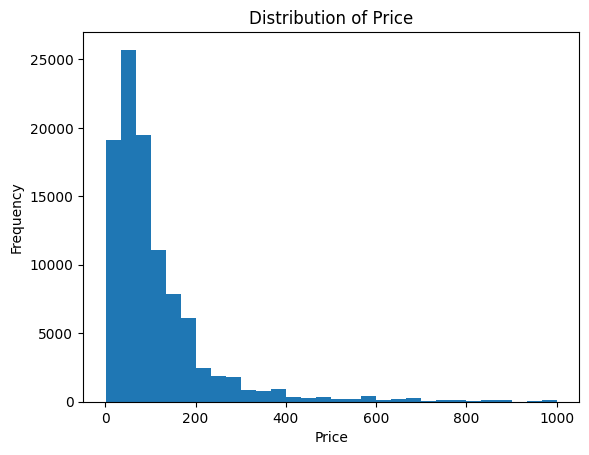

In [ ]:
plt.hist(filtered_df['price'],bins=30)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df['order_purchase_timestamp']=pd.to_datetime(df['order_purchase_timestamp'])
df['year']=df['order_purchase_timestamp'].dt.year
df['month']=df['order_purchase_timestamp'].dt.month
df['month_name']=df['order_purchase_timestamp'].dt.month_name()
df['day']=df['order_purchase_timestamp'].dt.day
df

,order_id,order_purchase_timestamp,order_status,price,freight_value,product_category_name,product_weight_g,year,month,month_name,day
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,delivered,29.99,8.72,utilidades_domesticas,500.0,2017,10,October,2
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,delivered,118.70,22.76,perfumaria,400.0,2018,7,July,24
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,delivered,159.90,19.22,automotivo,420.0,2018,8,August,8
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,delivered,45.00,27.20,pet_shop,450.0,2017,11,November,18
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,delivered,19.90,8.72,papelaria,250.0,2018,2,February,13
...,...,...,...,...,...,...,...,...,...,...,...
112644,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05,delivered,72.00,13.08,beleza_saude,1175.0,2017,3,March,9
112645,63943bddc261676b46f01ca7ac2f7bd8,2018-02-06 12:58:58,delivered,174.90,20.10,bebes,4950.0,2018,2,February,6
112646,83c1379a015df1e13d02aae0204711ab,2017-08-27 14:46:43,delivered,205.99,65.02,eletrodomesticos_2,13300.0,2017,8,August,27
112647,11c177c8e97725db2631073c19f07b62,2018-01-08 21:28:27,delivered,179.99,40.59,informatica_acessorios,6550.0,2018,1,January,8


In [ ]:
df.columns

Index(['order_id', 'order_purchase_timestamp', 'order_status', 'price',
       'freight_value', 'product_category_name', 'product_weight_g', 'year',
       'month', 'month_name', 'day'],
      dtype='object')

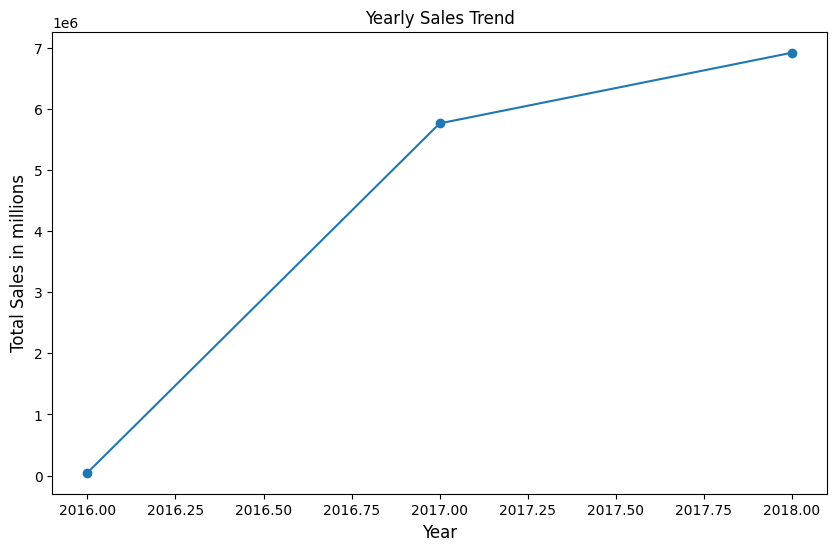

In [ ]:
# Yearly sales trend
yearly_sales=df.groupby('year')['price'].sum()
plt.figure(figsize=(10,6))
plt.plot(yearly_sales.index,yearly_sales.values,marker='o')
plt.title("Yearly Sales Trend")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Sales in millions", fontsize=12)
plt.show()

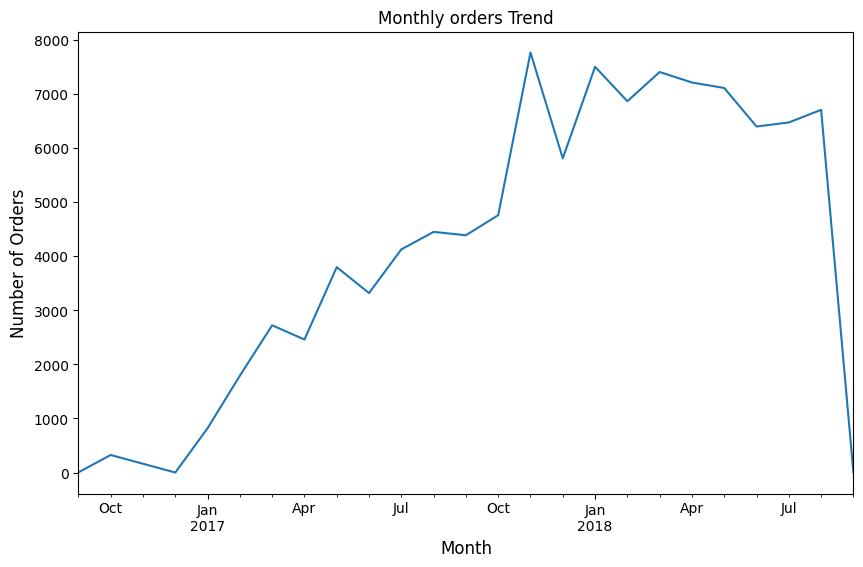

In [ ]:
df['month']=df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders=df.groupby('month')['order_id'].count()
monthly_orders.plot(figsize=(10,6))
plt.title("Monthly orders Trend")
plt.xlabel("Month", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)
plt.show()

Since we have data for 2016, 2017, and 2018, I'll plot the monthly sales trend with a separate line for each year to compare them.

In [ ]:
# Only keeing the data from Jan 2017 to Aug 2018
df=df[(df['order_purchase_timestamp']>='2017-01-01') & (df['order_purchase_timestamp']<='2018-08-01')]

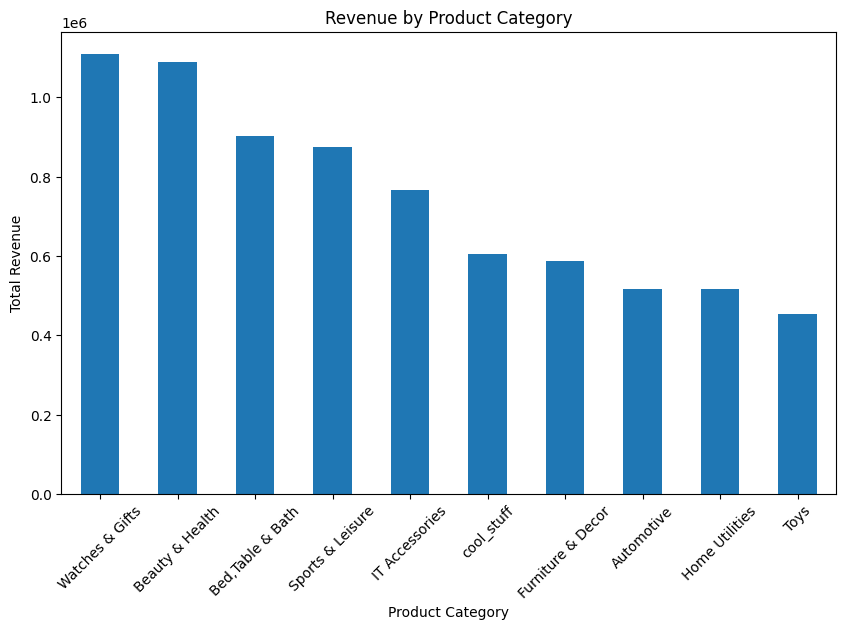

In [ ]:
# Top 10 product categories by sales
Product_translation={'beleza_saude':'Beauty & Health','relogios_presentes':'Watches & Gifts','cama_mesa_banho':'Bed,Table & Bath','esporte_lazer':'Sports & Leisure','informatica_acessorios':'IT Accessories','moveis_decoracao':'Furniture & Decor','cool_stuff':'cool_stuff','utilidades_domesticas':'Home Utilities','automotivo':'Automotive','brinquedos':'Toys'}
product_sales=df.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)
product_sales.index=product_sales.index.map(Product_translation)
plt.figure(figsize=(10,6))
product_sales.plot(kind='bar')
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()


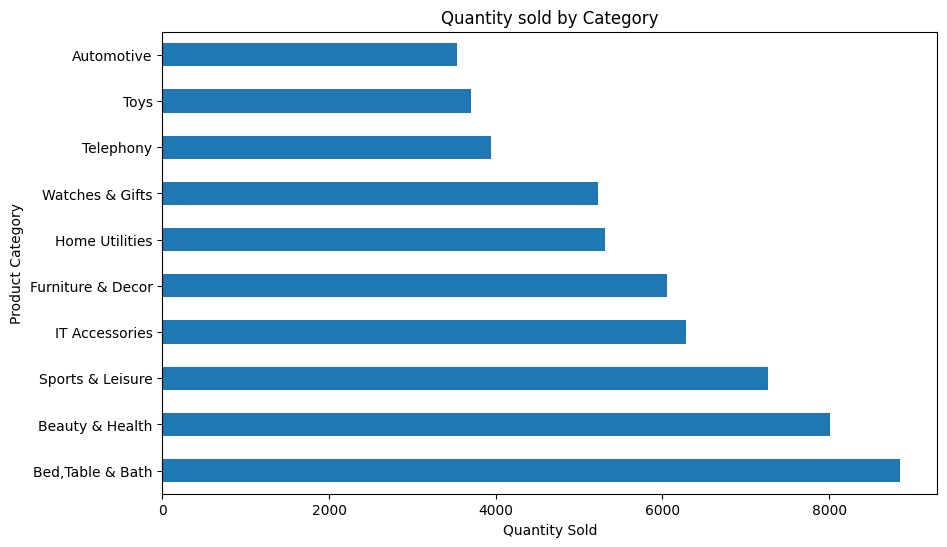

In [ ]:
Product_translation['fashion_bolsas_e_acessorios'] = 'Fashion Bags & Accessories'
Product_translation['Unknown'] = 'Unknown Category'
Product_translation['telefonia'] = 'Telephony'

# Re-calculate category_quantity with updated translation
category_quantity = df.groupby('product_category_name')['order_id'].nunique().sort_values(ascending=False).head(10)
category_quantity.index = category_quantity.index.map(Product_translation)

plt.figure(figsize=(10,6))
category_quantity.plot(kind='barh')
plt.title("Quantity sold by Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")
plt.show()


In [ ]:
# Monthly Revenue by top 10 product category

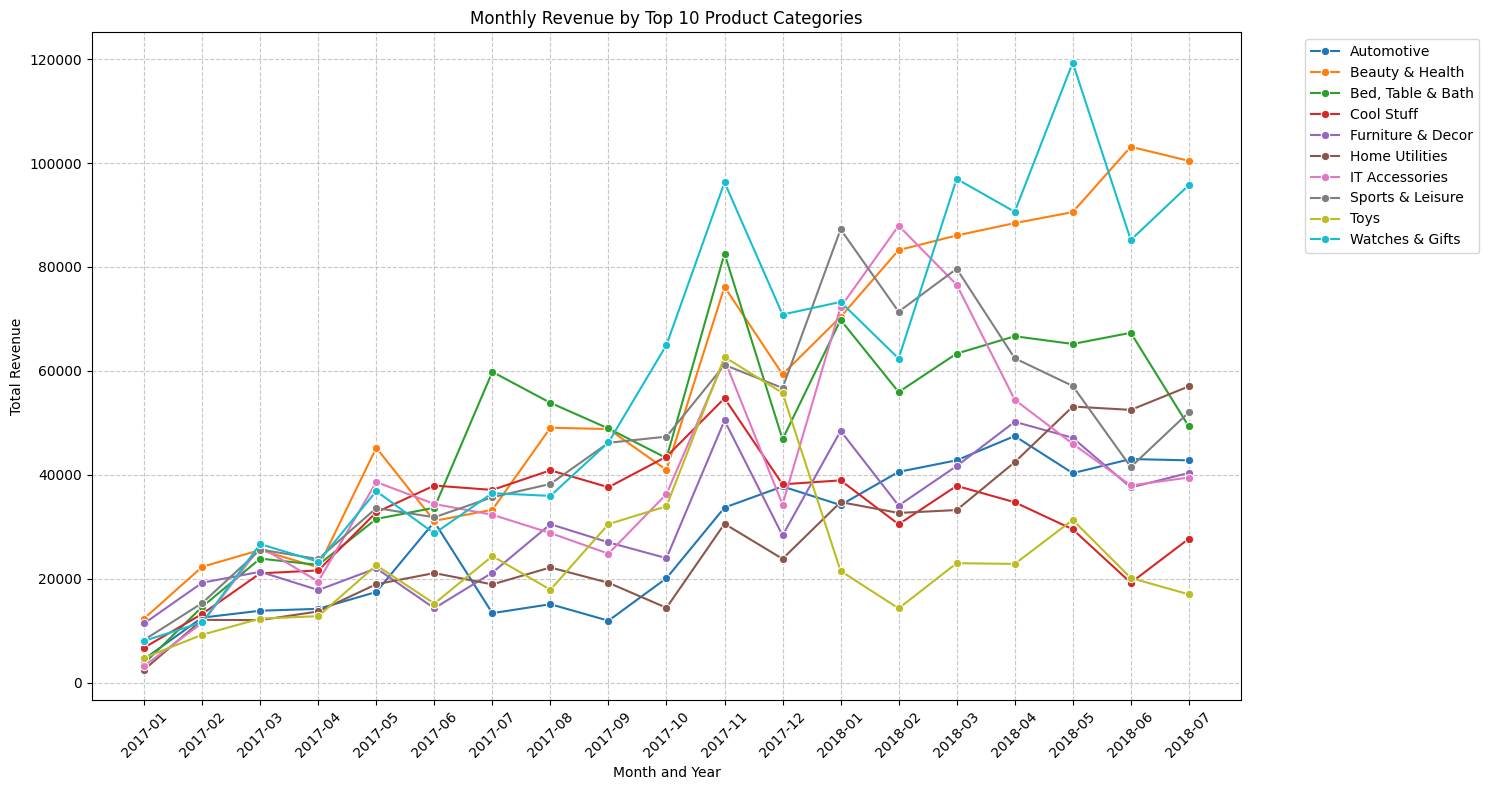

In [ ]:
df_translated['month_year_str'] = df_translated['order_purchase_timestamp'].dt.strftime('%Y-%m')

monthly_revenue_category = df_translated.groupby(['month_year_str', 'product_category_name'])['price'].sum().reset_index()

# Get the top 10 product categories based on overall revenue
top_10_categories = df_translated.groupby('product_category_name')['price'].sum().nlargest(10).index

# Filter the monthly revenue data for only the top 10 categories
monthly_revenue_top_10 = monthly_revenue_category[monthly_revenue_category['product_category_name'].isin(top_10_categories)]

plt.figure(figsize=(15, 8))
sns.lineplot(data=monthly_revenue_top_10, x='month_year_str', y='price', hue='product_category_name', marker='o')
plt.title('Monthly Revenue by Top 10 Product Categories')
plt.xlabel('Month and Year')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('my_graph3.png', dpi=300,bbox_inches='tight')
plt.show()

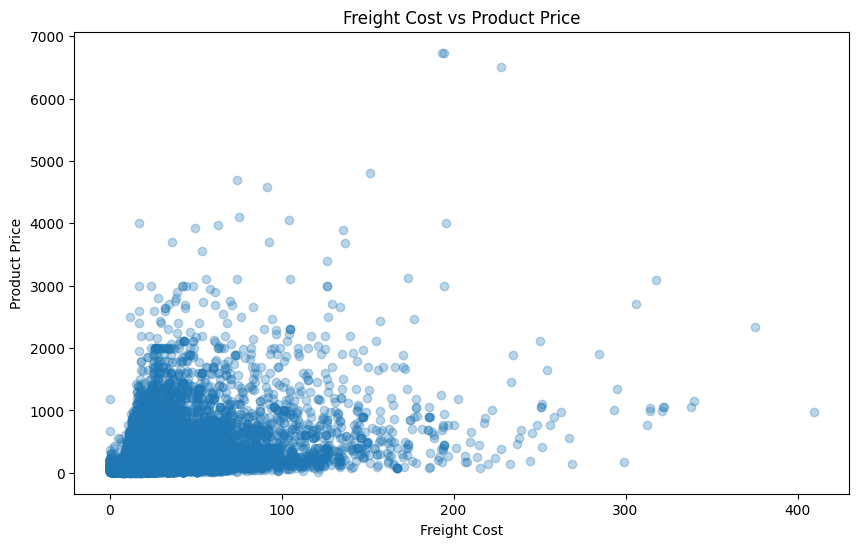

In [ ]:
#Freight Cost vs Product Price
plt.figure(figsize=(10,6))
plt.scatter(df['freight_value'],df['price'],alpha=0.3)
plt.title("Freight Cost vs Product Price")
plt.xlabel("Freight Cost")
plt.ylabel("Product Price")
plt.show()

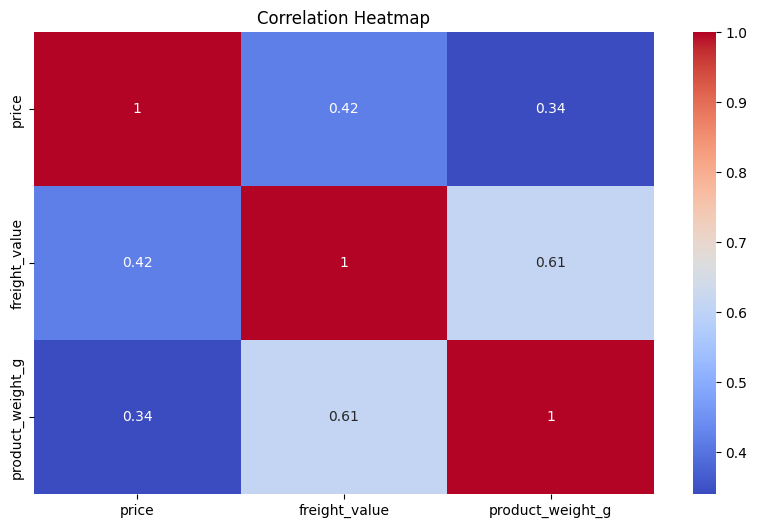

In [ ]:
numeric_data=df[['price','freight_value','product_weight_g']]
correlation=numeric_data.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation,annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.savefig('my_graph2.png', dpi=300,bbox_inches='tight')
plt.show()


In [ ]:
Product_translation={'beleza_saude':'Beauty & Health',
                    'relogios_presentes':'Watches & Gifts',
                    'cama_mesa_banho':'Bed, Table & Bath',
                    'esporte_lazer':'Sports & Leisure',
                    'informatica_acessorios':'IT Accessories',
                    'moveis_decoracao':'Furniture & Decor',
                    'cool_stuff':'Cool Stuff',
                    'utilidades_domesticas':'Home Utilities',
                    'automotivo':'Automotive',
                    'brinquedos':'Toys',
                    'perfumaria': 'Perfumery',
                    'telefonia': 'Telephony',
                    'fashion_bolsas_e_acessorios': 'Fashion Bags & Accessories',
                    'eletronicos': 'Electronics',
                    'papelaria': 'Stationery',
                    'consoles_games': 'Consoles & Games',
                    'construcao_ferramentas_seguranca': 'Construction Tools (Safety)',
                    'ferramentas_jardim': 'Garden Tools',
                    'agro_industria_e_comercio': 'Agro Industry & Commerce',
                    'eletrodomesticos': 'Home Appliances',
                    'livros_genero_literario': 'Books (Literary Genre)',
                    'moveis_escritorio': 'Office Furniture',
                    'casa_conforto': 'Home Comfort',
                    'eletroportateis': 'Portable Electronics',
                    'telefonia_fixa': 'Fixed Telephony',
                    'construcao_ferramentas_construcao': 'Construction Tools (Construction)',
                    'artes': 'Arts',
                    'instrumentos_musicais': 'Musical Instruments',
                    'pet_shop': 'Pet Shop',
                    'industria_comercio_e_negocios': 'Industry, Commerce & Business',
                    'livros_interesse_geral': 'Books (General Interest)',
                    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'Kitchen, Laundry, Dining & Garden Furniture',
                    'construcao_ferramentas_iluminacao': 'Construction Tools (Lighting)',
                    'eletrodomesticos_2': 'Home Appliances 2',
                    'bebidas': 'Drinks',
                    'portateis_casa_forno_e_cafe': 'Portable Home Appliances (Oven & Coffee)',
                    'la_cuisine': 'La Cuisine',
                    'casa_conforto_2': 'Home Comfort 2',
                    'pcs': 'PCs',
                    'moveis_sala': 'Living Room Furniture',
                    'flores': 'Flowers',
                    'alimentos': 'Food',
                    'eletronicos': 'Electronics',
                    'artigos_esportivos': 'Sporting Goods',
                    'sinalizacao_e_seguranca': 'Signaling & Security',
                    'fashion_calcados': 'Fashion Footwear',
                    'moveis_quarto': 'Bedroom Furniture',
                    'climatizacao': 'Air Conditioning',
                    'utilidades_domesticas': 'Home Utilities',
                    'fashion_roupa_masculina': 'Men`s Fashion',
                    'artigos_de_festas': 'Party Supplies',
                    'dvds_filmes': 'DVDs & Movies',
                    'fashion_esporte': 'Sports Fashion',
                    'cama_mesa_banho': 'Bed, Table & Bath',
                    'musica': 'Music',
                    'fashion_underwear_e_moda_praia': 'Underwear & Beachwear Fashion',
                    'livros_tecnicos': 'Technical Books',
                    'artigos_de_natal': 'Christmas Items',
                    'fashion_feminina': 'Women`s Fashion',
                    'cds_dvds_musicais': 'Musical CDs & DVDs',
                    'pc_gamer': 'PC Gamer',
                    'fraldas_higiene': 'Diapers & Hygiene',
                    'casa_construcao': 'Home Construction',
                    'malas_acessorios': 'Luggage & Accessories',
                    'tablets_impressao_imagem': 'Tablets, Printing & Imaging',
                    'fashion_male_underwear': 'Men`s Underwear Fashion',
                    'afazeres_domesticos': 'Household Chores',
                    'livros_importados': 'Imported Books',
                    'moveis_decoracao': 'Furniture & Decor',
                    'moveis_infantil': 'Children`s Furniture',
                    'artes_e_artesanato': 'Arts & Crafts',
                    'seguros_e_servicos': 'Insurance & Services',
                    'fashion_roupa_infanto_juvenil': 'Kids` Fashion',
                    'telefonia_fixa': 'Fixed Telephony',
                    'livros_ingles': 'English Books',
                    'Unknown': 'Unknown Category' # Added 'Unknown' category
                   }

df_translated = df.copy()
df_translated['product_category_name'] = df_translated['product_category_name'].replace(Product_translation)

relationship_analysis = df_translated.groupby('product_category_name').agg({
    'price':'mean',
    'freight_value':'mean',
    'order_id':'count',
    'product_weight_g':'mean'
}).reset_index()

#Rename columns
relationship_analysis.columns=['product_category_name','avg_price','avg_freight_value','total_orders','avg_product_weight']
relationship_analysis.head()

,product_category_name,avg_price,avg_freight_value,total_orders,avg_product_weight
0,Agro Industry & Commerce,354.884556,28.127396,169,3784.396450
1,Air Conditioning,181.546293,22.546422,232,3903.754310
2,Arts,121.607446,19.483913,184,1565.635870
3,Arts & Crafts,60.816667,13.522667,15,1175.133333
4,Automotive,142.979328,21.948322,3617,2696.408073


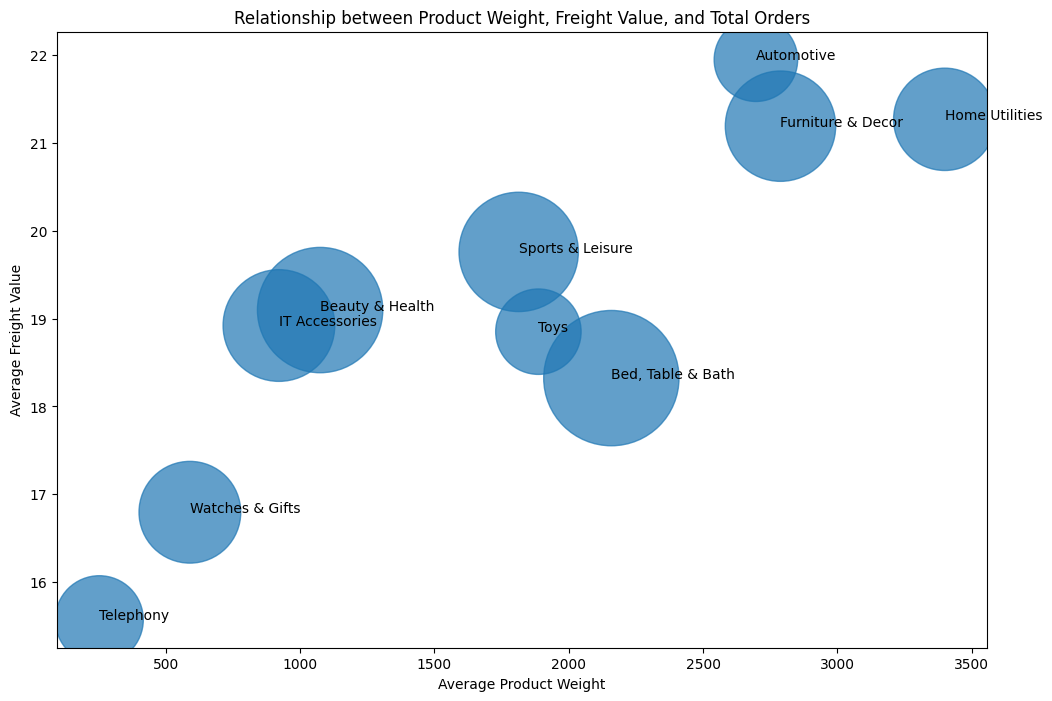

In [ ]:
#Top categories by total orders
top_data=relationship_analysis.sort_values(by='total_orders',ascending=False).head(10)
plt.figure(figsize=(12,8))
scatter=plt.scatter(top_data['avg_product_weight'],  #x-axis
                    top_data['avg_freight_value'],   #y-axis
                    s=top_data['total_orders'],      #Bubble
                    alpha=0.7)
for i, txt in enumerate(top_data['product_category_name']):
    plt.annotate(txt, (top_data['avg_product_weight'].iloc[i], top_data['avg_freight_value'].iloc[i]))

# labels and title
plt.xlabel('Average Product Weight')
plt.ylabel('Average Freight Value')
plt.title('Relationship between Product Weight, Freight Value, and Total Orders')
plt.savefig('my_graph.png', dpi=300,bbox_inches='tight')
plt.show()



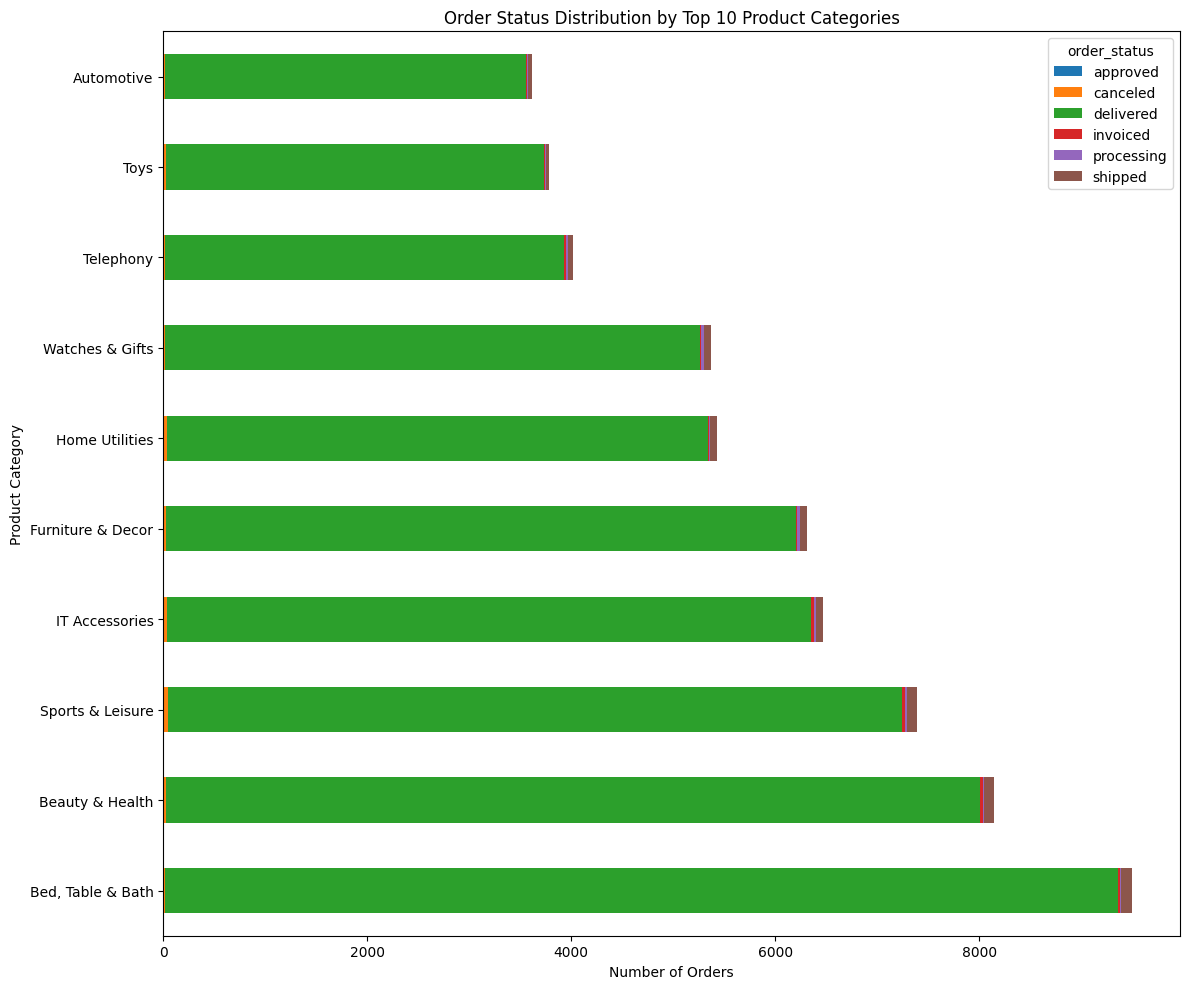

In [ ]:
status_counts = df.pivot_table(index='product_category_name', columns='order_status', values='order_id', aggfunc='count', fill_value=0)
# Apply translation to the index (product category names)
status_counts.index = status_counts.index.map(Product_translation)
# Sort by the total number of orders (sum across all statuses) for better visualization
status_counts_sorted = status_counts.sum(axis=1).sort_values(ascending=False)
# Select only the top 10 product categories
top_10_categories = status_counts_sorted.head(10).index
status_counts = status_counts.loc[top_10_categories]

status_counts.plot(kind='barh', stacked=True, figsize=(12, 10)) # Use barh for better label readability
plt.title("Order Status Distribution by Top 10 Product Categories")
plt.xlabel("Number of Orders") # Update xlabel for horizontal bar chart
plt.ylabel("Product Category") # Update ylabel for horizontal bar chart
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.savefig('my_graph1.png', dpi=300,bbox_inches='tight')
plt.show()